# Figure 2 - Brownian Motion vs Gradient Descent

This notebook reproduces the Section 4.2 case study on the true-label MNIST classification MDP.  The reusable MLP and true-label MDP live in `src.models.mlp` and `configs.environments.easy_mdp`; this notebook keeps the run broken into inspectable steps.

In [1]:
from pathlib import Path
import sys
import os

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
OUTPUT_ROOT.mkdir(exist_ok=True)
MPLCONFIGDIR = OUTPUT_ROOT / "matplotlib_cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

ROOT

PosixPath('/Users/mahdigheidi/Documents/Univ/Masters-Study-Project')

## Imports

The experiment helper contains the Q-learning loop, Brownian update, gradient covariance, Hessian ESD, and plotting code.  The model and environment definitions it uses are shared with the later notebooks.

In [ ]:
import pandas as pd
import torch

from experiments.figure2_true_label_mdp import (
    DEVICE,
    Figure2Config,
    QNetwork,
    EasyMDP,
    load_true_label_mnist,
    run_experiment,
    plot_results,
)

DEVICE

device(type='cpu')

## Configuration

This default is intentionally a smoke-scale run.  Increase `train_steps`, `prefill_steps`, and set `compute_hessian=True` when you want a closer paper-scale reproduction.

In [3]:
cfg = Figure2Config(
    seed=0,
    data_root=str(DATA_ROOT),
    download=False,
    hidden_dim=512,
    train_steps=0,
    snapshot_target_updates=(1, 5),
    probe_batch_size=128,
    cov_batch_size=512,
    lanczos_iter=100,
    lanczos_vectors=1,
    compute_hessian=True,
    output_path=str(OUTPUT_ROOT / "figure2_brownian_motion_reproduction.png"),
)

cfg

Figure2Config(seed=0, data_root='/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/data', download=False, hidden_dim=512, gamma=0.99, lr=0.001, batch_size=512, replay_capacity=50000, prefill_steps=50000, train_steps=0, target_update_period=5000, epsilon=0.1, online_collection_per_step=100, probe_batch_size=128, cov_batch_size=512, lanczos_iter=100, lanczos_vectors=1, esd_points=600, esd_sigma=None, snapshot_target_updates=(1, 5), esd_xlim=(0.0, 50.0), esd_ylim=(0.0, 0.4), esd_xtick_step=10.0, esd_ytick_step=0.1, covariance_vmin=-1.0, covariance_vmax=1.0, compute_hessian=True, output_path='/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/outputs/figure2_brownian_motion_reproduction.png')

## Sanity Check the Shared Components

Before running the long loop, instantiate the shared MLP and true-label MDP, then step the environment once.

In [4]:
dataset = load_true_label_mnist(cfg.data_root, cfg.download)
env = EasyMDP(dataset, seed=cfg.seed)
model = QNetwork(cfg.hidden_dim).to(DEVICE)

obs = env.reset(state=3)
next_obs, reward, next_state = env.step(action=3)
print("obs", tuple(obs.shape))

print("reward", reward, "next_state", next_state)
print("q_values", tuple(model(obs.unsqueeze(0).to(DEVICE)).shape))

obs (1, 28, 28)
reward 1.0 next_state 0
q_values (1, 10)


## Run the Experiment

The run couples two trajectories from the same initialization: one follows SGD on the Q-learning objective, and the other receives Brownian parameter perturbations with the same update norm.

In [5]:
results = run_experiment(cfg)

pd.DataFrame(results["logs"]).tail()

Device: cpu
Config: {'seed': 0, 'data_root': '/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/data', 'download': False, 'hidden_dim': 512, 'gamma': 0.99, 'lr': 0.001, 'batch_size': 512, 'replay_capacity': 50000, 'prefill_steps': 50000, 'train_steps': 0, 'target_update_period': 5000, 'epsilon': 0.1, 'online_collection_per_step': 100, 'probe_batch_size': 128, 'cov_batch_size': 512, 'lanczos_iter': 100, 'lanczos_vectors': 1, 'esd_points': 600, 'esd_sigma': None, 'snapshot_target_updates': (1, 5), 'esd_xlim': (0.0, 50.0), 'esd_ylim': (0.0, 0.4), 'esd_xtick_step': 10.0, 'esd_ytick_step': 0.1, 'covariance_vmin': -1.0, 'covariance_vmax': 1.0, 'compute_hessian': True, 'output_path': '/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/outputs/figure2_brownian_motion_reproduction.png'}


0it [00:00, ?it/s]

No requested target-update snapshots were reached; computing final geometry.


""


## Plot Figure 2 Panels

With `compute_hessian=False`, the figure shows the gradient covariance panels only.  Turn Hessian computation on in the config to add the ESD row.

Saved figure to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/outputs/figure2_brownian_motion_reproduction.png


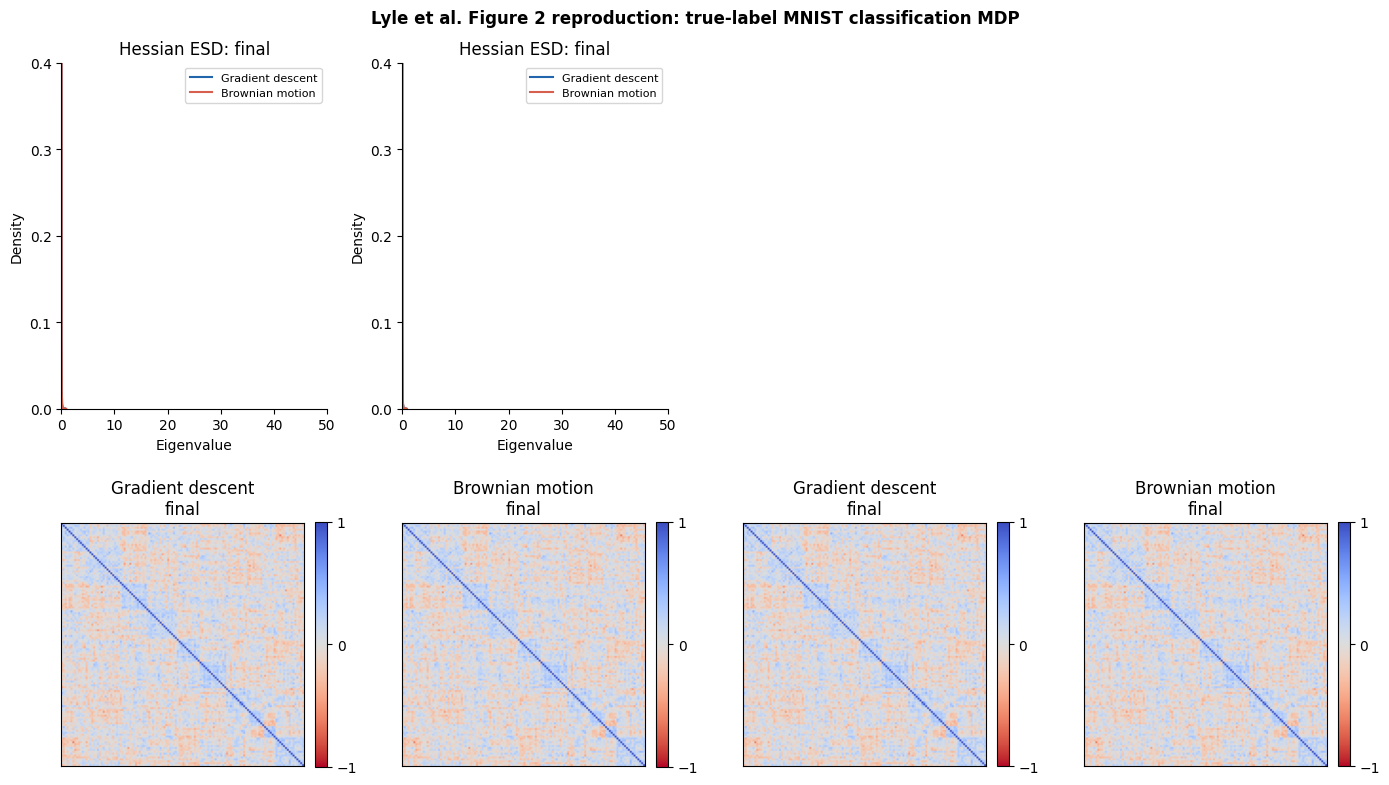

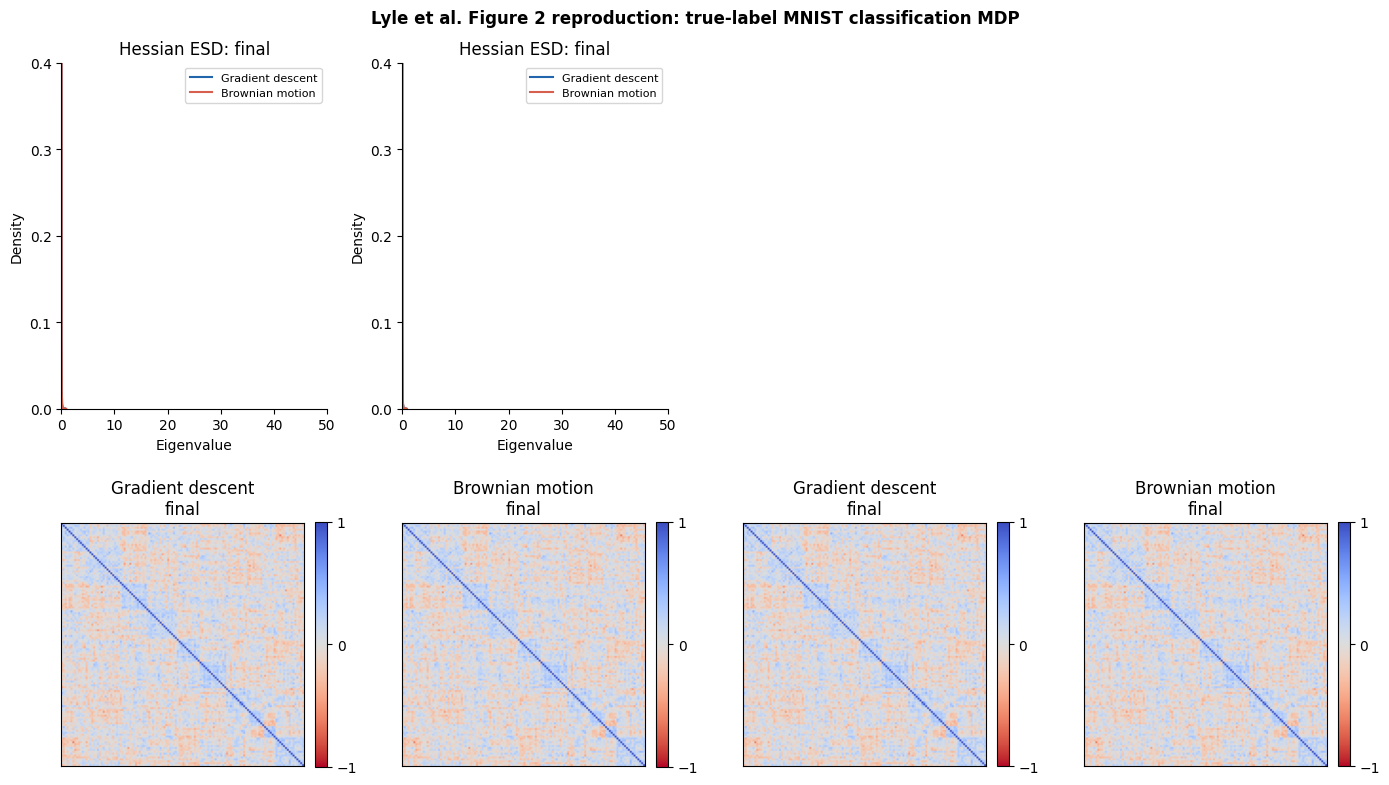

In [6]:
fig = plot_results(results, cfg.output_path)
fig

## Paper-Scale Starting Point

The helper exposes the main scale changes from Appendix A.1.  This cell does not run by default; it is here as a concrete reference for a heavier reproduction.

In [7]:
# from dataclasses import replace
# from experiments.section4.figure2_true_label_mdp import PAPER_SCALE_OVERRIDES
#
# paper_cfg = replace(cfg, **PAPER_SCALE_OVERRIDES, compute_hessian=True)
# paper_cfg